In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("nlptask.csv")


In [3]:
print(df['sentiment'].unique())
print(df['sentiment'].isnull().sum())
print(df['original_text'].isnull().sum())
print(df['retweet_count'].isnull().sum())
print(df['favorite_count'].isnull().sum())


['pos' 'neg' 'neu' nan]
1
0
2
2


In [4]:
df = df.dropna(subset=['sentiment','retweet_count','favorite_count'])
print(df['sentiment'].isnull().sum())
print(df['retweet_count'].isnull().sum())
print(df['favorite_count'].isnull().sum())

0
0
0


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"^rt\s+", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['original_text'].apply(clean_text)

In [6]:
df.head(10)

,Unnamed: 0,id,created_at,source,original_text,lang,favorite_count,retweet_count,hashtags,user_mentions,place,compound,neg,neu,pos,sentiment,clean_text
0,0,1386694264550270000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @VP: The U.S. is working closely with the I...,en,0.0,0.0,NaN,VP,Alabama,0.0772,0.170,0.638,0.191,pos,vp the us is working closely with the indian g...
1,1,1386694260213170000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...",RT @JackPosobiec: Flip-Flop Fauci admits outdo...,en,0.0,0.0,NaN,JackPosobiec,NaN,-0.4019,0.398,0.442,0.159,neg,jackposobiec flipflop fauci admits outdoor cov...
2,2,1386694256413320000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...","RT @timmy315: Hi Twitter, I’m Tim Manning, the...",en,0.0,252.0,NaN,timmy315,NaN,0.0000,0.000,1.000,0.000,neu,timmy hi twitter im tim manning the white hous...
3,3,1386694252017630000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",RT @itsaadee: Praying for #India as the countr...,en,0.0,2.0,"India, Covid",itsaadee,NaN,-0.4215,0.306,0.522,0.172,neg,itsaadee praying for india as the country batt...
4,4,1386694248284700000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",Rapid Investment in Nursing to Strengthen the ...,en,0.0,7937.0,NaN,NaN,UK,0.3182,0.000,0.723,0.277,pos,rapid investment in nursing to strengthen the ...
5,5,1386694243893210000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @GopiKishorRaja2: #Vizag ప్రజలకు ముఖ్య గమని...,en,0.0,140.0,"Vizag, GITAM, GAYTRI, GITAM, Gayatri",GopiKishorRaja2,"Hyderabad, India",0.0000,0.000,1.000,0.000,neu,gopikishorraja vizag \n \ngitam amp gaytri ...
6,6,1386694239963070000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @VPSecretariat: Pleased to learn that @Micr...,en,0.0,45.0,NaN,"VPSecretariat, Microsoft, satyanadella",NaN,0.0000,0.000,1.000,0.000,neu,vpsecretariat pleased to learn that microsoft ...
7,7,1386694234380580000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",COVID-19: Legal action launched after Italian ...,en,0.0,66.0,"covid19, vaccines",YouTube,home,0.1280,0.000,0.857,0.143,pos,covid legal action launched after italian woma...
8,8,1386694231566260000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...",6-Ft Rule Doesn't Stop COVID-19 Spread Indoors...,en,0.0,581.0,NaN,"StrangRobert, IainTRankin, LisaBarrettID","Nova Scotia, Canada",-0.2960,0.239,0.761,0.000,neg,ft rule doesnt stop covid spread indoors mit s...
9,9,1386694227220900000,2021-04-26,"<a href=""https://about.twitter.com/products/tw...","Please be aware, the ECDOH has scheduled three...",en,0.0,46.0,NaN,NaN,NaN,0.0000,0.000,1.000,0.000,neu,please be aware the ecdoh has scheduled three ...


In [7]:
y = df['sentiment']
X_text_original = df['clean_text']

In [8]:
num_features = df[['favorite_count', 'retweet_count']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_scaled = scaler.fit_transform(num_features)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df['sentiment']

X_text = df['clean_text']


In [10]:
from scipy.sparse import hstack

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_text_vector = vectorizer.fit_transform(X_text)
X = hstack([X_text_vector, num_scaled])

X_train_vec, X_test_vec, y_train, y_test, text_train, text_test = train_test_split(
    X_text_vector,
    y,
    X_text_original,
    test_size=0.2,
    random_state=42
)


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9099332220367279
              precision    recall  f1-score   support

         neg       0.95      0.81      0.88      5760
         neu       0.87      0.99      0.93     10914
         pos       0.95      0.87      0.91      7286

    accuracy                           0.91     23960
   macro avg       0.92      0.89      0.90     23960
weighted avg       0.91      0.91      0.91     23960



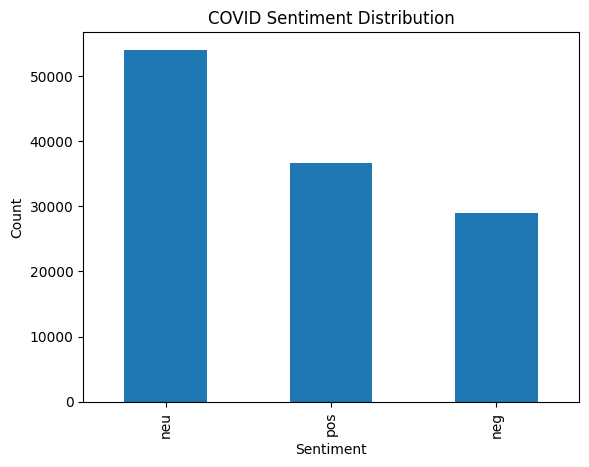

In [13]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("COVID Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


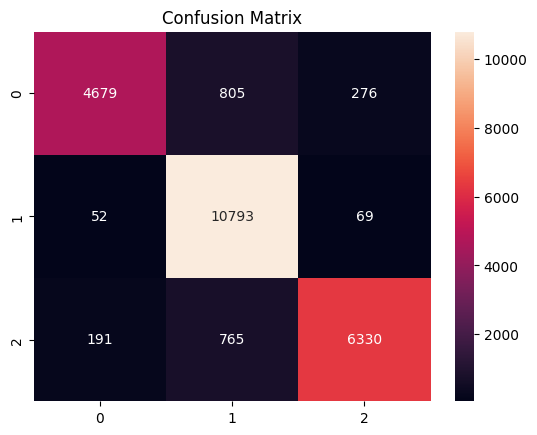

In [14]:
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


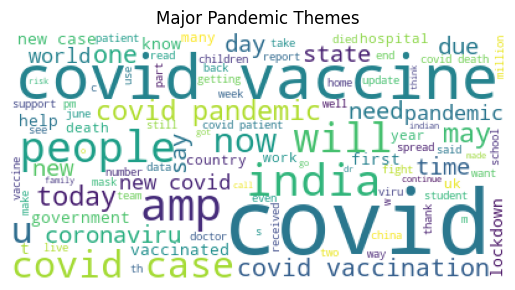

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(df['clean_text'])

wc = WordCloud(background_color='white',
               max_words=100).generate(text_all)

plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.title("Major Pandemic Themes")
plt.show()


In [16]:
predictions = model.predict(X_test_vec)

for i in range(4):
    print("Text:", text_test.iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", predictions[i])
    print("-"*50)

Text: ukdomainnames long said vietnam would soon publish genome data of the newly identified variant which he said was more transmissibl
Actual: neu
Predicted: neu
--------------------------------------------------
Text: cmoguj gujarat govt adds one more 
dedicated covid hospital to its set of corona treatment facilities as a bed dhanvantari covi
Actual: neu
Predicted: neu
--------------------------------------------------
Text: ctvbarrienews covid cases continue to stabilize but premier ford isnt ready to decide whether to send students back to class  h
Actual: neu
Predicted: neu
--------------------------------------------------
Text: bbosnation extremely proud uncle moment my niece clcowan pitcher was not able to have a senior season amp chase another state due
Actual: pos
Predicted: pos
--------------------------------------------------


In [17]:
import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    
    labels = {"pos": "😊 Positive", "neg": "😠 Negative", "neu": "😐 Neutral"}
    return labels.get(prediction, prediction)

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a COVID-related tweet..."),
    outputs=gr.Label(label="Sentiment"),
    title="COVID Tweet Sentiment Analyzer",
    examples=[
        ["Vaccines are saving lives and we are finally seeing hope!"],
        ["Another lockdown is destroying the economy and mental health."],
        ["WHO releases new guidelines on COVID-19 protocols."]
    ]
)

demo.launch()

c:\Users\abanz\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
